# Visualizations — RAG-Driven Data Cleaning with PyDI

This notebook loads results from all experiments and generates figures for the seminar report and presentation.

## Result Files Expected
| File | Experiment |
|------|------------|
| `results_exp8_1_llm_only.csv` | Exp 1 — LLM-only baseline |
| `results_exp8_1_rag.csv` | Exp 2 — RAG clean KB |
| `results_exp9_all.csv` | Exp 3 — RAG confusing KB |
| `results_exp10_easy_rag.csv` | Exp 4a — RAG + CrossEncoder clean KB |
| `results_exp10_confusing_rag.csv` | Exp 4b — RAG + CrossEncoder confusing KB |
| `results_exp11_bge_rag.csv` | Exp 5 — BGE-large + CrossEncoder clean KB |
| `results_rerank_fullKB_rag.csv` | Exp 4a rerun (if available) |

## Figures Generated
1. Overall accuracy bar chart (all 6 configs)
2. Per-attribute heatmap (standard accuracy)
3. UNKNOWN rate comparison
4. Retrieval quality (Hit@k) bar chart
5. LLM-only vs RAG improvement per attribute
6. Evaluation method comparison (standard vs semantic)

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# ── Style ─────────────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'figure.dpi': 150,
})

NAVY   = '#0D1B2A'
TEAL   = '#0891B2'
GOLD   = '#F59E0B'
GREEN  = '#0D9488'
RED    = '#E11D48'
GREY   = '#64748B'

OUTPUT_DIR = 'figures'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f'Figures will be saved to: {OUTPUT_DIR}/')

Figures will be saved to: figures/


## 2. Load All Result Files

In [2]:
def load_if_exists(path, config_label, eval_col='llm_judgment'):
    """Load a CSV and assign a config label. Returns None if file not found."""
    if not os.path.exists(path):
        print(f'  ⚠️  Not found: {path}')
        return None
    df = pd.read_csv(path)
    df['config'] = config_label
    # Normalise judgment column name
    if 'ce_judgment' in df.columns and 'llm_judgment' not in df.columns:
        df['llm_judgment'] = df['ce_judgment']
    print(f'  ✓ Loaded {path}: {len(df)} rows')
    return df

print('Loading result files...')

# Exp 1 — LLM-only
exp1 = load_if_exists('results_exp8_1_llm_only.csv', 'LLM-only')

# Exp 2 — RAG clean KB
exp2 = load_if_exists('results_exp8_1_rag.csv', 'RAG (clean KB)')

# Exp 3 — RAG confusing KB
# Try both possible file names
exp3 = load_if_exists('results_exp9_all.csv', 'RAG (confusing KB)')
if exp3 is not None:
    exp3 = exp3[exp3['config'] == 'RAG (confusing KB)'].copy() if 'RAG (confusing KB)' in exp3['config'].values else exp3[exp3['config'] == 'RAG'].copy()
    exp3['config'] = 'RAG (confusing KB)'

# Exp 4a — RAG + CrossEncoder clean KB
exp4a = load_if_exists('results_exp10_easy_rag.csv', 'RAG+Reranker (clean)')
if exp4a is None:
    exp4a = load_if_exists('results_rerank_fullKB_rag.csv', 'RAG+Reranker (clean)')

# Exp 4b — RAG + CrossEncoder confusing KB
exp4b = load_if_exists('results_exp10_confusing_rag.csv', 'RAG+Reranker (confusing)')

# Exp 5 — BGE + CrossEncoder clean KB
exp5 = load_if_exists('results_exp11_bge_rag.csv', 'BGE+Reranker (clean)')

# Combine all available
all_dfs = [df for df in [exp1, exp2, exp3, exp4a, exp4b, exp5] if df is not None]
all_results = pd.concat(all_dfs, ignore_index=True)

print(f'\nTotal tasks loaded: {len(all_results)}')
print('\nTasks per config:')
print(all_results['config'].value_counts().to_string())

Loading result files...
  ✓ Loaded results_exp8_1_llm_only.csv: 51 rows
  ✓ Loaded results_exp8_1_rag.csv: 51 rows
  ✓ Loaded results_exp9_all.csv: 102 rows
  ✓ Loaded results_exp10_easy_rag.csv: 51 rows
  ⚠️  Not found: results_exp10_confusing_rag.csv
  ✓ Loaded results_exp11_bge_rag.csv: 51 rows

Total tasks loaded: 306

Tasks per config:
config
RAG (confusing KB)      102
LLM-only                 51
RAG (clean KB)           51
RAG+Reranker (clean)     51
BGE+Reranker (clean)     51


## 3. Figure 1 — Overall Accuracy Bar Chart
Shows standard accuracy and UNKNOWN rate across all 6 configurations.

              config  standard_acc  unknown_rate  semantic_acc
            LLM-only         0.157         0.549         0.157
      RAG (clean KB)         0.569         0.196         0.549
  RAG (confusing KB)         0.373         0.314         0.392
RAG+Reranker (clean)         0.706         0.176         0.745
BGE+Reranker (clean)         0.706         0.137         0.745


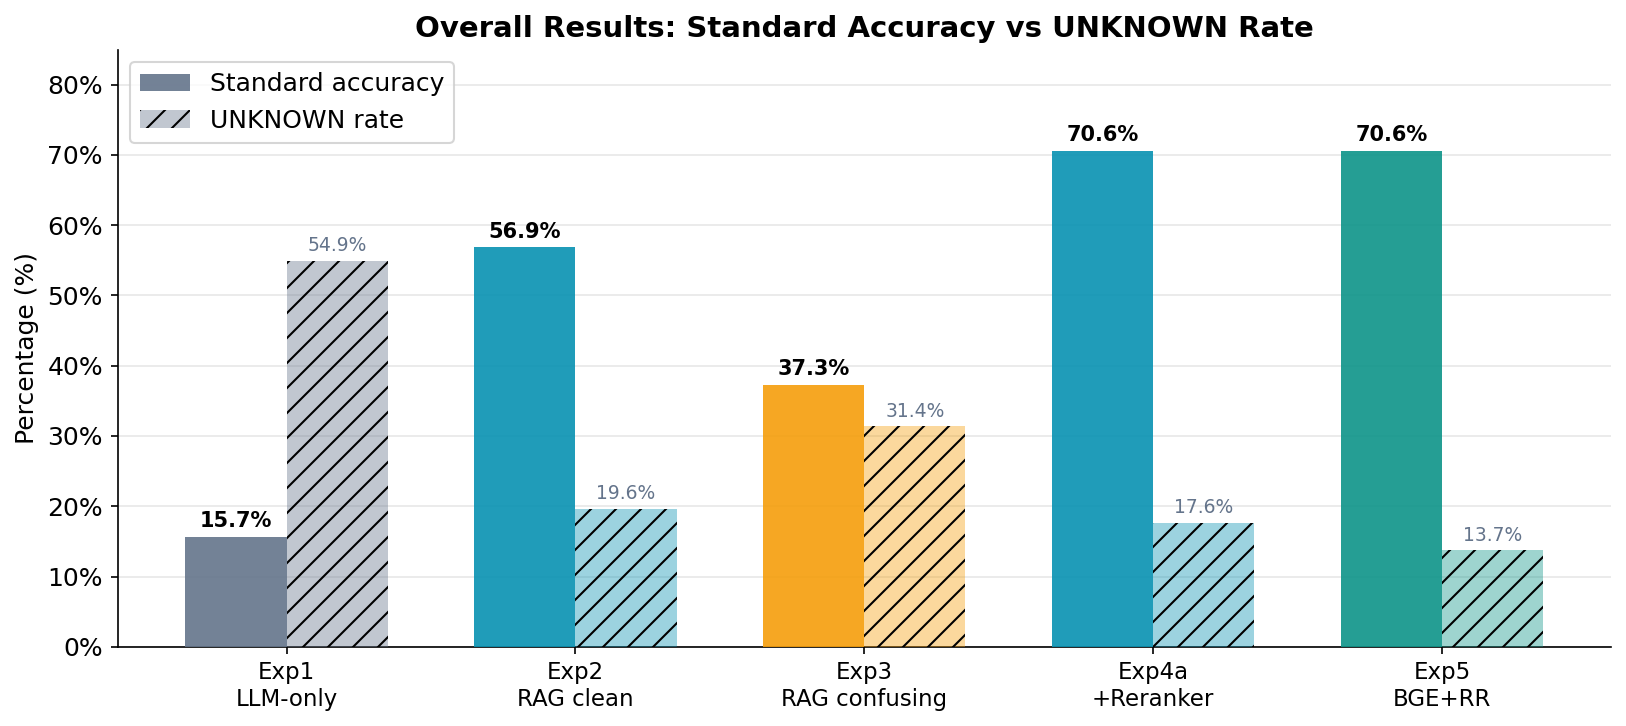

✓ Saved to figures/fig1_overall_accuracy.png


In [3]:
# Config order for all charts
CONFIG_ORDER = [
    'LLM-only',
    'RAG (clean KB)',
    'RAG (confusing KB)',
    'RAG+Reranker (clean)',
    'RAG+Reranker (confusing)',
    'BGE+Reranker (clean)',
]
CONFIG_COLORS = [GREY, TEAL, GOLD, TEAL, GOLD, GREEN]
CONFIG_SHORT  = ['Exp1\nLLM-only', 'Exp2\nRAG clean', 'Exp3\nRAG confusing',
                 'Exp4a\n+Reranker', 'Exp4b\nConfusing+RR', 'Exp5\nBGE+RR']

# Compute per-config metrics
summary = []
for cfg in CONFIG_ORDER:
    df_c = all_results[all_results['config'] == cfg]
    if len(df_c) == 0:
        continue
    summary.append({
        'config': cfg,
        'standard_acc': df_c['correct_standard'].mean(),
        'unknown_rate': df_c['unknown'].mean(),
        'semantic_acc': (df_c['llm_judgment'].isin(['correct','acceptable'])).mean()
                        if 'llm_judgment' in df_c.columns else np.nan,
    })

summary_df = pd.DataFrame(summary)
print(summary_df.round(3).to_string(index=False))

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

n = len(summary_df)
x = np.arange(n)
w = 0.35

colors = [CONFIG_COLORS[CONFIG_ORDER.index(c)] for c in summary_df['config']]
labels = [CONFIG_SHORT[CONFIG_ORDER.index(c)] for c in summary_df['config']]

bars1 = ax.bar(x - w/2, summary_df['standard_acc'] * 100, w,
               color=colors, alpha=0.9, label='Standard accuracy', zorder=3)
bars2 = ax.bar(x + w/2, summary_df['unknown_rate'] * 100, w,
               color=colors, alpha=0.4, hatch='//', label='UNKNOWN rate', zorder=3)

# Value labels on bars
for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.8,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9, color=GREY)

ax.set_xticks(x)
ax.set_xticklabels(labels, fontsize=11)
ax.set_ylabel('Percentage (%)')
ax.set_title('Overall Results: Standard Accuracy vs UNKNOWN Rate')
ax.set_ylim(0, 85)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig1_overall_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to {OUTPUT_DIR}/fig1_overall_accuracy.png')

## 4. Figure 2 — Per-Attribute Heatmap (Standard Accuracy)
The main comparison heatmap across all configurations.

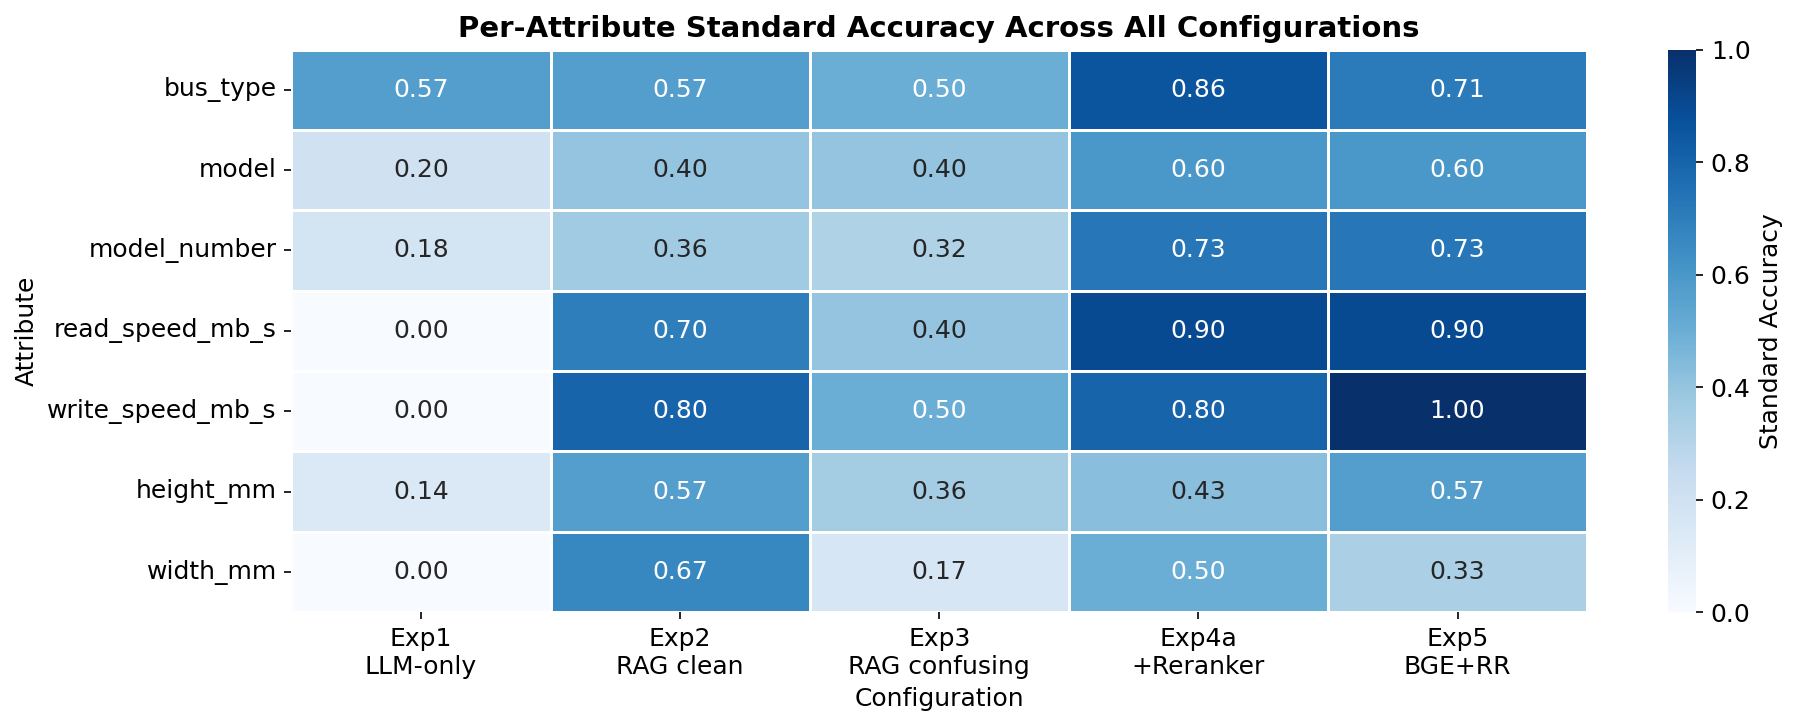

✓ Saved to figures/fig2_per_attribute_heatmap.png


In [4]:
ATTR_ORDER = ['bus_type', 'model', 'model_number',
              'read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']

available_configs = [c for c in CONFIG_ORDER if c in all_results['config'].values]

heatmap_data = (
    all_results.groupby(['attribute', 'config'])['correct_standard']
    .mean()
    .unstack('config')
    .reindex(index=ATTR_ORDER, columns=available_configs)
)

# Short column labels
col_labels = {
    'LLM-only':                  'Exp1\nLLM-only',
    'RAG (clean KB)':            'Exp2\nRAG clean',
    'RAG (confusing KB)':        'Exp3\nRAG confusing',
    'RAG+Reranker (clean)':      'Exp4a\n+Reranker',
    'RAG+Reranker (confusing)':  'Exp4b\nConfusing+RR',
    'BGE+Reranker (clean)':      'Exp5\nBGE+RR',
}
heatmap_data.columns = [col_labels.get(c, c) for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.2f',
    cmap='Blues', vmin=0, vmax=1,
    linewidths=0.5, linecolor='white',
    ax=ax, cbar_kws={'label': 'Standard Accuracy'}
)
ax.set_title('Per-Attribute Standard Accuracy Across All Configurations')
ax.set_xlabel('Configuration')
ax.set_ylabel('Attribute')
ax.tick_params(axis='x', rotation=0)
ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig2_per_attribute_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to {OUTPUT_DIR}/fig2_per_attribute_heatmap.png')

## 5. Figure 3 — Numeric vs Text Attributes: LLM-only vs Best RAG
Shows the dramatic difference retrieval makes for numeric attributes.

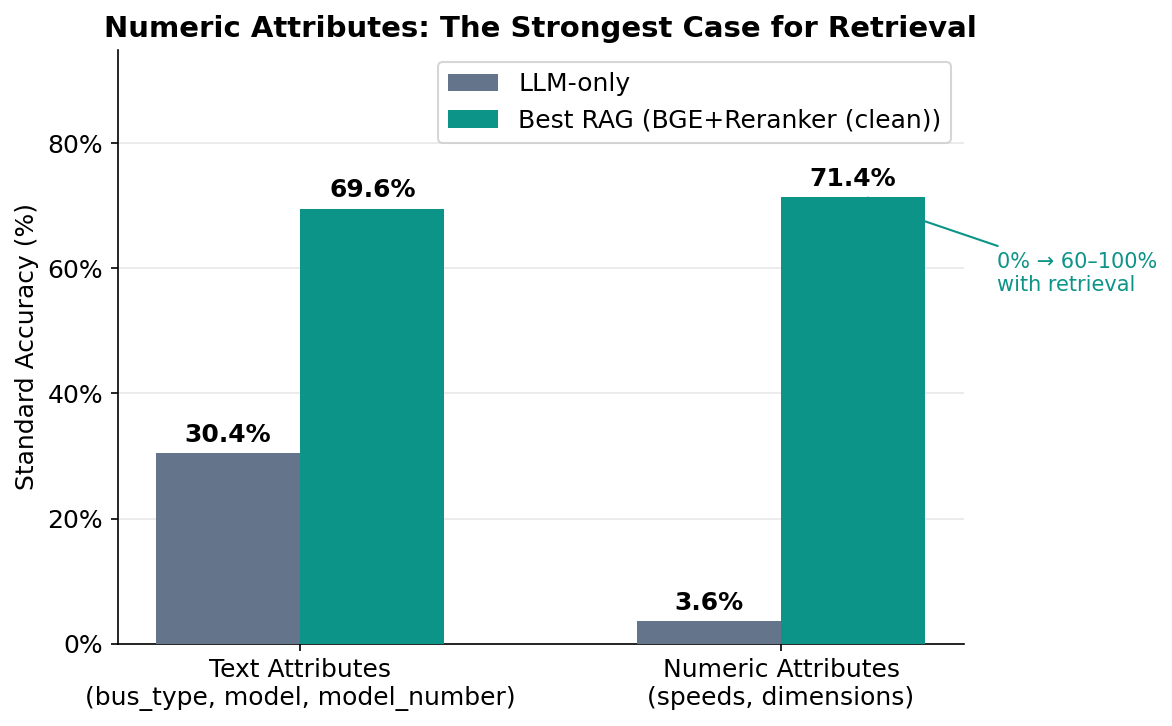

✓ Saved to figures/fig3_numeric_vs_text.png


In [5]:
NUMERIC_ATTRS = ['read_speed_mb_s', 'write_speed_mb_s', 'height_mm', 'width_mm']
TEXT_ATTRS    = ['bus_type', 'model', 'model_number']

def get_acc(config, attrs):
    df_c = all_results[(all_results['config'] == config) &
                       (all_results['attribute'].isin(attrs))]
    if len(df_c) == 0:
        return np.nan
    return df_c['correct_standard'].mean()

# Use best available config for comparison
best_config = 'BGE+Reranker (clean)' if 'BGE+Reranker (clean)' in all_results['config'].values \
              else 'RAG+Reranker (clean)'

categories  = ['Text Attributes\n(bus_type, model, model_number)',
                'Numeric Attributes\n(speeds, dimensions)']
llm_vals    = [get_acc('LLM-only', TEXT_ATTRS),    get_acc('LLM-only', NUMERIC_ATTRS)]
best_vals   = [get_acc(best_config, TEXT_ATTRS),   get_acc(best_config, NUMERIC_ATTRS)]

x  = np.arange(2)
w  = 0.3

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, [v * 100 for v in llm_vals],  w, color=GREY,  label='LLM-only',      zorder=3)
b2 = ax.bar(x + w/2, [v * 100 for v in best_vals], w, color=GREEN, label=f'Best RAG ({best_config})', zorder=3)

for bar in b1 + b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 1,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(categories, fontsize=12)
ax.set_ylabel('Standard Accuracy (%)')
ax.set_title('Numeric Attributes: The Strongest Case for Retrieval')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()

# Annotation
ax.annotate('0% → 60–100%\nwith retrieval',
            xy=(1 + w/2, best_vals[1]*100), xytext=(1.45, best_vals[1]*100 - 15),
            fontsize=10, color=GREEN,
            arrowprops=dict(arrowstyle='->', color=GREEN))

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig3_numeric_vs_text.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to {OUTPUT_DIR}/fig3_numeric_vs_text.png')

## 6. Figure 4 — Retrieval Quality (Hit@k)
Shows how retrieval quality changes across configurations.

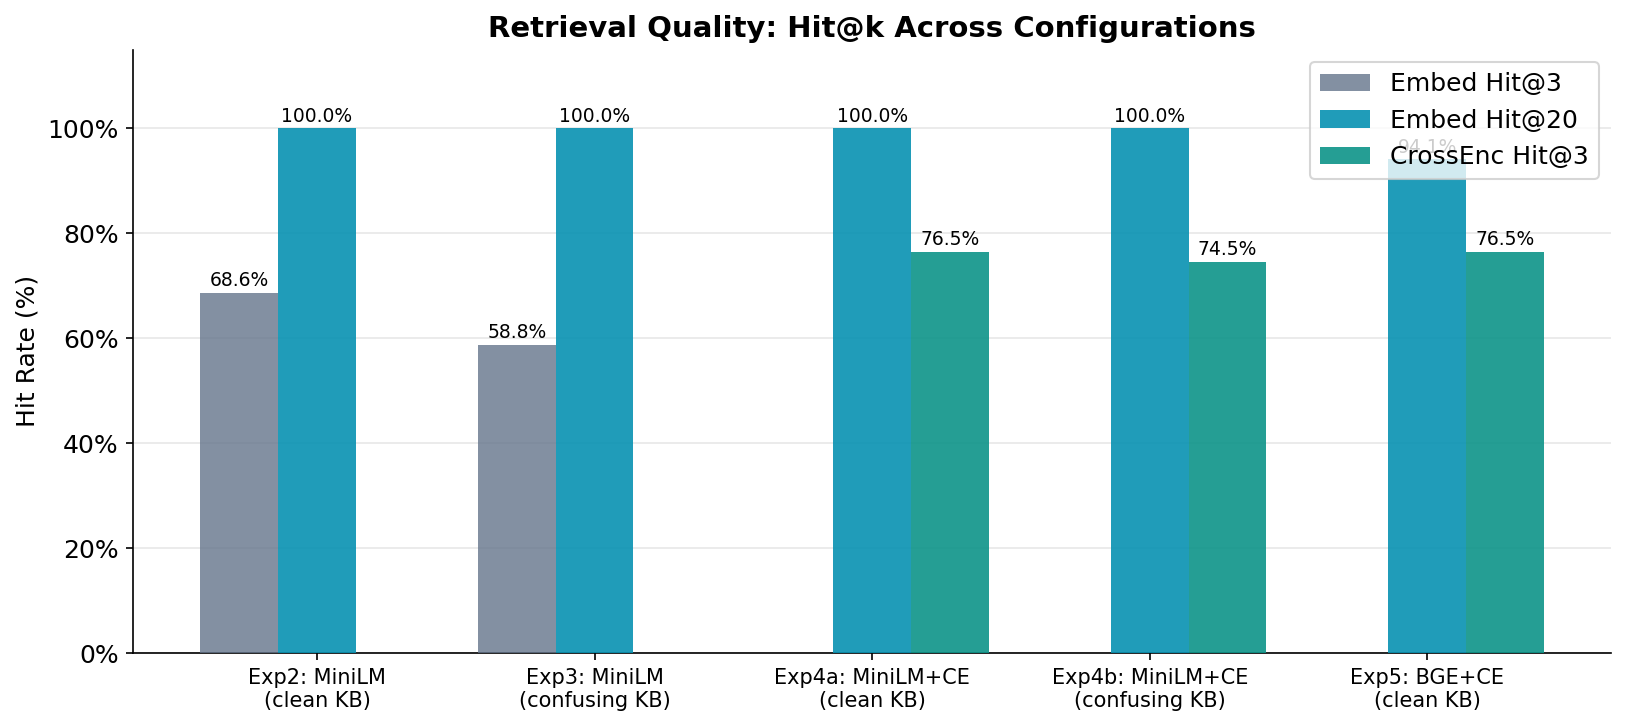

✓ Saved to figures/fig4_retrieval_quality.png


In [6]:
# Hit@k results from experiments (manually entered from output logs)
hitk_data = {
    'Configuration': [
        'Exp2: MiniLM\n(clean KB)',
        'Exp3: MiniLM\n(confusing KB)',
        'Exp4a: MiniLM+CE\n(clean KB)',
        'Exp4b: MiniLM+CE\n(confusing KB)',
        'Exp5: BGE+CE\n(clean KB)',
    ],
    'Embed Hit@3':  [68.6, 58.8, None, None, None],
    'Embed Hit@20': [100.0, 100.0, 100.0, 100.0, 94.1],
    'CrossEnc Hit@3': [None, None, 76.5, 74.5, 76.5],
}

hitk_df = pd.DataFrame(hitk_data)

fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(hitk_df))
w = 0.28

# Embed Hit@3
vals3 = [v if v is not None else 0 for v in hitk_df['Embed Hit@3']]
alpha3 = [0.9 if v is not None else 0.0 for v in hitk_df['Embed Hit@3']]
bars3 = ax.bar(x - w, vals3, w, color=GREY, alpha=0.8, label='Embed Hit@3', zorder=3)

# Embed Hit@20
vals20 = [v if v is not None else 0 for v in hitk_df['Embed Hit@20']]
bars20 = ax.bar(x, vals20, w, color=TEAL, alpha=0.9, label='Embed Hit@20', zorder=3)

# CrossEnc Hit@3
valsCE = [v if v is not None else 0 for v in hitk_df['CrossEnc Hit@3']]
barsCE = ax.bar(x + w, valsCE, w, color=GREEN, alpha=0.9, label='CrossEnc Hit@3', zorder=3)

# Labels
for i, (b3, b20, bCE) in enumerate(zip(bars3, bars20, barsCE)):
    if hitk_df['Embed Hit@3'][i] is not None:
        ax.text(b3.get_x() + b3.get_width()/2, b3.get_height() + 0.5,
                f"{hitk_df['Embed Hit@3'][i]:.1f}%", ha='center', va='bottom', fontsize=9)
    ax.text(b20.get_x() + b20.get_width()/2, b20.get_height() + 0.5,
            f"{hitk_df['Embed Hit@20'][i]:.1f}%", ha='center', va='bottom', fontsize=9)
    if hitk_df['CrossEnc Hit@3'][i] is not None:
        ax.text(bCE.get_x() + bCE.get_width()/2, bCE.get_height() + 0.5,
                f"{hitk_df['CrossEnc Hit@3'][i]:.1f}%", ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(hitk_df['Configuration'], fontsize=10)
ax.set_ylabel('Hit Rate (%)')
ax.set_title('Retrieval Quality: Hit@k Across Configurations')
ax.set_ylim(0, 115)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig4_retrieval_quality.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to {OUTPUT_DIR}/fig4_retrieval_quality.png')

## 7. Figure 5 — Standard vs Semantic Evaluation Gap
Shows how standard matching underestimates true accuracy.

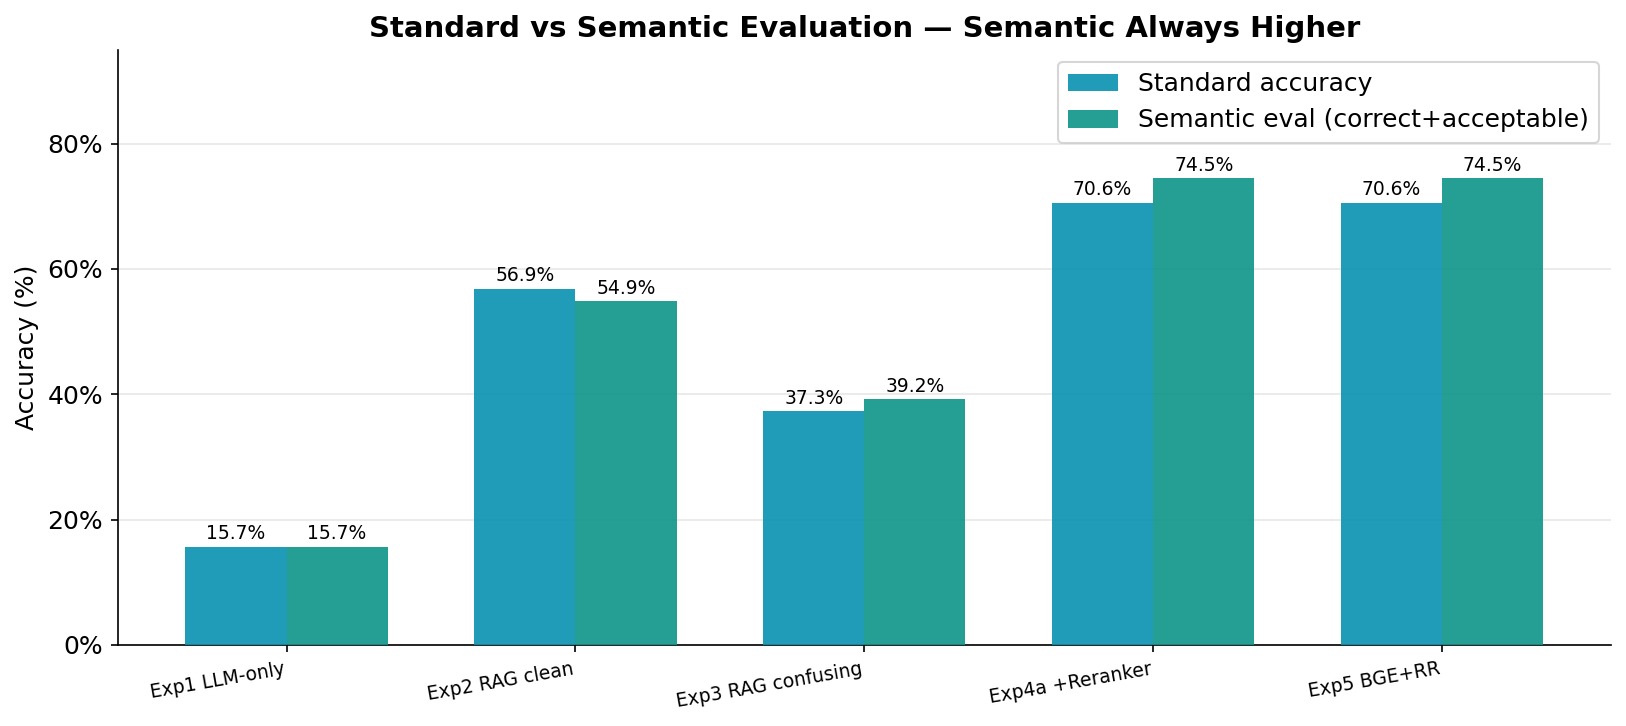

✓ Saved to figures/fig5_eval_comparison.png


In [7]:
eval_summary = []
for cfg in CONFIG_ORDER:
    df_c = all_results[all_results['config'] == cfg]
    if len(df_c) == 0:
        continue
    std  = df_c['correct_standard'].mean()
    sem  = (df_c['llm_judgment'].isin(['correct','acceptable'])).mean() \
           if 'llm_judgment' in df_c.columns else np.nan
    eval_summary.append({'config': cfg, 'standard': std, 'semantic': sem})

eval_df = pd.DataFrame(eval_summary).dropna()
short_labels = [col_labels.get(c, c).replace('\n', ' ') for c in eval_df['config']]

x  = np.arange(len(eval_df))
w  = 0.35

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - w/2, eval_df['standard'] * 100, w,
            color=TEAL, alpha=0.9, label='Standard accuracy', zorder=3)
b2 = ax.bar(x + w/2, eval_df['semantic'] * 100, w,
            color=GREEN, alpha=0.9, label='Semantic eval (correct+acceptable)', zorder=3)

for bar in b1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9)
for bar in b2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
            f'{h:.1f}%', ha='center', va='bottom', fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(short_labels, fontsize=9, rotation=10, ha='right')
ax.set_ylabel('Accuracy (%)')
ax.set_title('Standard vs Semantic Evaluation — Semantic Always Higher')
ax.set_ylim(0, 95)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.grid(axis='y', alpha=0.3, zorder=0)
ax.legend()

plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}/fig5_eval_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✓ Saved to {OUTPUT_DIR}/fig5_eval_comparison.png')

## 8. Figure 6 — MiniLM vs BGE-large Comparison
Direct comparison of the two embedding models.

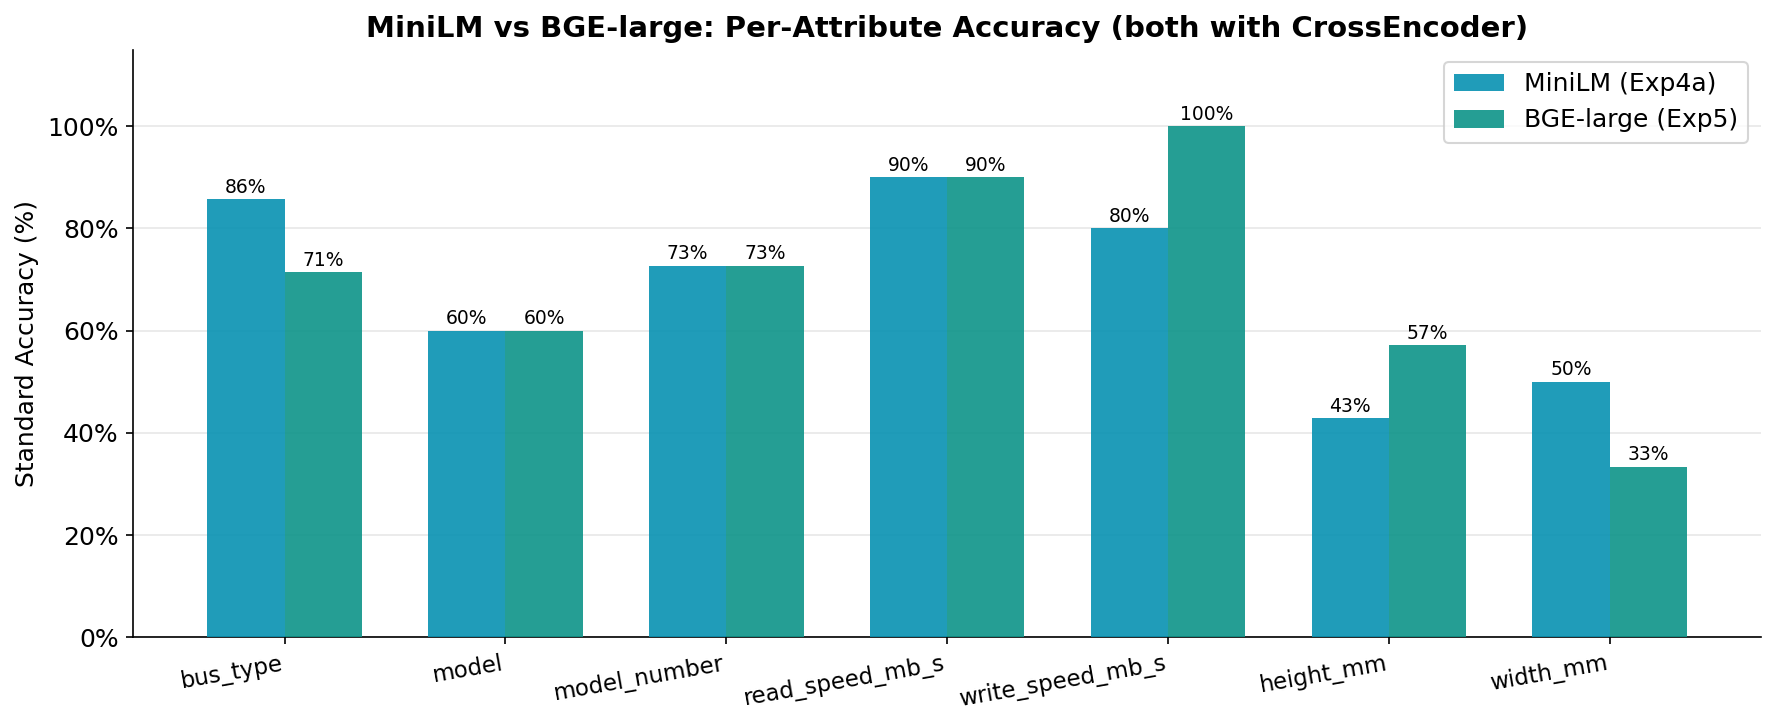

✓ Saved to figures/fig6_minilm_vs_bge.png


In [8]:
if 'BGE+Reranker (clean)' in all_results['config'].values and \
   'RAG+Reranker (clean)' in all_results['config'].values:

    minilm_df = all_results[all_results['config'] == 'RAG+Reranker (clean)']
    bge_df    = all_results[all_results['config'] == 'BGE+Reranker (clean)']

    attrs = ATTR_ORDER
    minilm_acc = [minilm_df[minilm_df['attribute'] == a]['correct_standard'].mean() * 100
                  for a in attrs]
    bge_acc    = [bge_df[bge_df['attribute'] == a]['correct_standard'].mean() * 100
                  for a in attrs]

    x = np.arange(len(attrs))
    w = 0.35

    fig, ax = plt.subplots(figsize=(12, 5))
    b1 = ax.bar(x - w/2, minilm_acc, w, color=TEAL,  alpha=0.9, label='MiniLM (Exp4a)', zorder=3)
    b2 = ax.bar(x + w/2, bge_acc,    w, color=GREEN, alpha=0.9, label='BGE-large (Exp5)', zorder=3)

    for bar in b1 + b2:
        h = bar.get_height()
        if not np.isnan(h):
            ax.text(bar.get_x() + bar.get_width()/2, h + 0.5,
                    f'{h:.0f}%', ha='center', va='bottom', fontsize=9)

    ax.set_xticks(x)
    ax.set_xticklabels(attrs, fontsize=11, rotation=10, ha='right')
    ax.set_ylabel('Standard Accuracy (%)')
    ax.set_title('MiniLM vs BGE-large: Per-Attribute Accuracy (both with CrossEncoder)')
    ax.set_ylim(0, 115)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.grid(axis='y', alpha=0.3, zorder=0)
    ax.legend()

    plt.tight_layout()
    plt.savefig(f'{OUTPUT_DIR}/fig6_minilm_vs_bge.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'✓ Saved to {OUTPUT_DIR}/fig6_minilm_vs_bge.png')

else:
    print('BGE or Reranker results not found — skipping this figure.')

## 9. Summary — All Figures Saved

In [9]:
saved = [f for f in os.listdir(OUTPUT_DIR) if f.endswith('.png')]
print(f'All figures saved to ./{OUTPUT_DIR}/')
print()
for f in sorted(saved):
    print(f'  {f}')

print()
print('Use these in your report and presentation:')
print('  fig1 → Overall results slide')
print('  fig2 → Per-attribute heatmap (main results table as visual)')
print('  fig3 → Numeric attributes killer use case slide')
print('  fig4 → Retrieval quality slide')
print('  fig5 → Evaluation methodology slide')
print('  fig6 → BGE vs MiniLM slide')

All figures saved to ./figures/

  fig1_overall_accuracy.png
  fig2_per_attribute_heatmap.png
  fig3_numeric_vs_text.png
  fig4_retrieval_quality.png
  fig5_eval_comparison.png
  fig6_minilm_vs_bge.png

Use these in your report and presentation:
  fig1 → Overall results slide
  fig2 → Per-attribute heatmap (main results table as visual)
  fig3 → Numeric attributes killer use case slide
  fig4 → Retrieval quality slide
  fig5 → Evaluation methodology slide
  fig6 → BGE vs MiniLM slide
